In [ ]:
# 📊 AI-Powered Financial Image Scanner
# 
# This notebook analyzes financial document images and converts them into
# clear, structured financial insights using Google Gemini AI.
#
# Author: [Dharun TR]
# Date: [02.07.2026]

In [ ]:
# !pip install pillow opencv-python google-generativeai python-dotenv matplotlib numpy

In [ ]:
import os
import time
import re
import json
import requests
import getpass
from PIL import Image, ImageEnhance
from dotenv import load_dotenv
import google.generativeai as genai
import matplotlib.pyplot as plt
from io import BytesIO

print("="*60)
print("🔑 Gemini API Configuration")
print("="*60)

# Load environment variables (if .env exists)
load_dotenv()

# Try to get API key from .env first
api_key = os.getenv("GEMINI_API_KEY")

# If no .env file or key not found, ask the user
if not api_key:
    print("\n📌 No API key found in .env file.")
    print("Please enter your Gemini API key.")
    print("Get your free key at: https://makersuite.google.com/app/apikey")
    print("-"*50)
    
    api_key = getpass.getpass("Enter your API Key: ").strip()
    
    if not api_key:
        raise ValueError("❌ API key is required. Please restart and enter a valid key.")

# Configure Gemini
try:
    genai.configure(api_key=api_key)
    print("\n✅ Gemini API configured successfully!")
    print(f"🔑 Key validated: {api_key[:10]}...")
except Exception as e:
    print(f"\n❌ Error configuring API: {e}")
    raise

# Test the connection
print("🔄 Testing API connection...")
try:
    model = genai.GenerativeModel('models/gemini-2.0-flash')
    response = model.generate_content("Hello, test connection")
    print("✅ API connection successful!")
except Exception as e:
    print(f"⚠️ API test failed: {e}")
    print("You may still be able to use the notebook if the key is valid.")

print("="*60)
print("✅ All libraries imported successfully!")
print(f"✅ Gemini configured successfully!")

🔑 Gemini API Configuration

✅ Gemini API configured successfully!
🔑 Key validated: AQ.Ab8RN6K...
🔄 Testing API connection...
⚠️ API test failed: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
Please retry in 28.184630373s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelang

In [ ]:
def load_image(image_path):
    """
    Load an image from local path or URL
    
    Args:
        image_path: Local file path or URL starting with http
        
    Returns:
        PIL Image object or None if error
    """
    try:
        if image_path.startswith('http'):
            # Load from URL
            print(f"📥 Downloading image from URL: {image_path}")
            response = requests.get(image_path, timeout=10)
            response.raise_for_status()
            img = Image.open(BytesIO(response.content))
            print(f"✅ Image downloaded successfully! Size: {img.size}")
        else:
            # Load from local file
            print(f"📁 Loading image from file: {image_path}")
            img = Image.open(image_path)
            print(f"✅ Image loaded successfully! Size: {img.size}")
        return img
    except Exception as e:
        print(f"❌ Error loading image: {e}")
        return None

print("✅ Image loading function ready!")

✅ Image loading function ready!


In [ ]:
def preprocess_image(image, resize=True, enhance_contrast=True):
    """
    Preprocess image for better AI analysis
    
    Args:
        image: PIL Image object
        resize: Whether to resize large images
        enhance_contrast: Whether to enhance contrast
        
    Returns:
        Preprocessed PIL Image
    """
    try:
        # Convert to RGB if needed
        if image.mode != 'RGB':
            image = image.convert('RGB')
            print("   🔄 Converted to RGB")
        
        # Resize if too large (max 1024x1024)
        if resize:
            max_size = 1024
            ratio = min(max_size/image.width, max_size/image.height)
            if ratio < 1:
                new_size = (int(image.width*ratio), int(image.height*ratio))
                image = image.resize(new_size, Image.Resampling.LANCZOS)
                print(f"   📏 Resized to: {new_size}")
        
        # Enhance contrast
        if enhance_contrast:
            enhancer = ImageEnhance.Contrast(image)
            image = enhancer.enhance(1.2)
            print("   ✨ Contrast enhanced")
        
        return image
    except Exception as e:
        print(f"❌ Error preprocessing image: {e}")
        return image

def preview_image(image, title="Financial Image"):
    """
    Display image with matplotlib
    
    Args:
        image: PIL Image object
        title: Title for the image
    """
    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print("✅ Image preprocessing functions ready!")

✅ Image preprocessing functions ready!


✅ Sample financial image created at: sample_images/realistic_financial.png


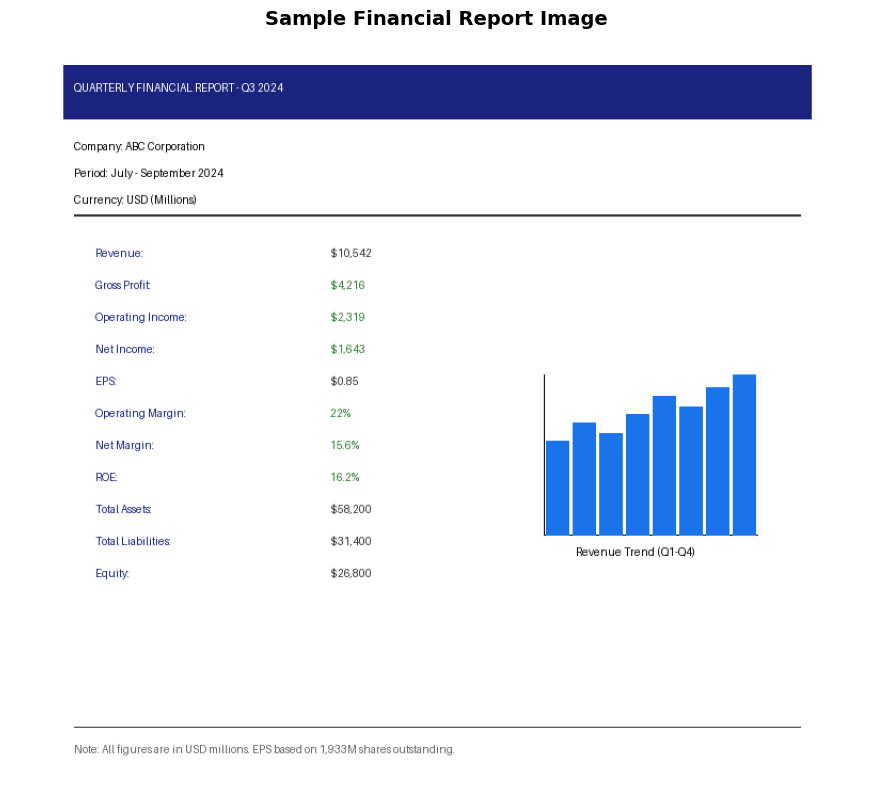

In [ ]:
def create_sample_financial_image():
    """
    Create a realistic-looking financial report image for testing
    
    Returns:
        PIL Image object
    """
    # Create a blank image
    img = Image.new('RGB', (800, 700), color='white')
    draw = ImageDraw.Draw(img)
    
    # Add a title
    draw.rectangle([50, 30, 750, 80], fill='#1a237e')
    draw.text((60, 45), "QUARTERLY FINANCIAL REPORT - Q3 2024", fill='white')
    
    # Add company info
    draw.text((60, 100), "Company: ABC Corporation", fill='black')
    draw.text((60, 125), "Period: July - September 2024", fill='black')
    draw.text((60, 150), "Currency: USD (Millions)", fill='black')
    
    # Draw a line
    draw.line([(60, 170), (740, 170)], fill='#333', width=2)
    
    # Add financial metrics
    metrics = {
        "Revenue": "$10,542",
        "Gross Profit": "$4,216",
        "Operating Income": "$2,319",
        "Net Income": "$1,643",
        "EPS": "$0.85",
        "Operating Margin": "22%",
        "Net Margin": "15.6%",
        "ROE": "16.2%",
        "Total Assets": "$58,200",
        "Total Liabilities": "$31,400",
        "Equity": "$26,800"
    }
    
    y = 200
    for i, (key, value) in enumerate(metrics.items()):
        draw.text((80, y), f"{key}:", fill='#1a237e')
        draw.text((300, y), value, fill='#2e7d32' if 'Income' in key or 'Profit' in key or 'Margin' in key or 'ROE' in key else '#333')
        y += 30
    
    # Add a mini chart (simple bar chart)
    bar_data = [35, 42, 38, 45, 52, 48, 55, 60]
    chart_x = 500
    chart_y_start = 470
    chart_width = 200
    chart_height = 150
    
    # Draw axes
    draw.line([(chart_x, chart_y_start), (chart_x + chart_width, chart_y_start)], fill='black', width=1)
    draw.line([(chart_x, chart_y_start), (chart_x, chart_y_start - chart_height)], fill='black', width=1)
    
    # Draw bars
    bar_width = chart_width // len(bar_data) - 4
    for i, value in enumerate(bar_data):
        bar_height = (value / max(bar_data)) * chart_height
        x = chart_x + i * (bar_width + 4) + 2
        y = chart_y_start - bar_height
        draw.rectangle([x, y, x + bar_width, chart_y_start], fill='#1a73e8')
    
    draw.text((chart_x + 30, chart_y_start + 10), "Revenue Trend (Q1-Q4)", fill='black')
    
    # Add summary note
    draw.line([(60, 650), (740, 650)], fill='#333', width=1)
    draw.text((60, 665), "Note: All figures are in USD millions. EPS based on 1,933M shares outstanding.", fill='#666')
    
    return img

# Create and save the test image
from PIL import ImageDraw

sample_img = create_sample_financial_image()
sample_img.save('sample_images/realistic_financial.png')
print("✅ Sample financial image created at: sample_images/realistic_financial.png")

# Preview the image
preview_image(sample_img, "Sample Financial Report Image")

In [ ]:
def create_financial_analysis_prompt():
    """
    Create a structured prompt for financial image analysis
    
    Returns:
        String containing the analysis prompt
    """
    prompt = """
You are a professional financial analyst assistant. Analyze the provided financial document image and provide a structured summary.

Please extract and analyze the following:

1. **Key Financial Metrics Found:**
   - List all visible financial numbers, ratios, and metrics (Revenue, Profit, EPS, ROE, NIM, etc.)
   - Include the values and their units (M, B, %, bps)

2. **Income & Expense Analysis:**
   - What is the revenue/income trend?
   - What are the major expenses?
   - Is the company profitable? (Net income positive/negative)

3. **Balance Sheet/Capital Highlights:**
   - Total assets, liabilities, equity (if visible)
   - Capital ratios, risk indicators

4. **Chart/Visual Analysis:**
   - What type of chart is shown? (bar, line, pie)
   - What trend does it show?
   - Any notable patterns or anomalies?

5. **Risks or Concerns:**
   - Any negative trends or warning signs
   - Declining metrics, high expenses, etc.

6. **Period Comparisons:**
   - Compare current period vs previous periods
   - Identify YoY or QoQ changes

7. **Summary & Outlook:**
   - Overall financial health
   - Key strengths
   - Areas of concern

**Important Rules:**
- Only report numbers/values you can clearly see
- If a value is unclear, state "Not clearly visible"
- Do not hallucinate or invent numbers
- Be specific and business-focused
- Use a professional, concise tone

Please analyze the image thoroughly and provide a structured response.
"""
    return prompt

# Test the prompt
prompt = create_financial_analysis_prompt()
print("✅ Financial analysis prompt created!")
print(f"📝 Prompt length: {len(prompt)} characters")
print("\n--- First 200 characters ---")
print(prompt[:200] + "...")

✅ Financial analysis prompt created!
📝 Prompt length: 1447 characters

--- First 200 characters ---

You are a professional financial analyst assistant. Analyze the provided financial document image and provide a structured summary.

Please extract and analyze the following:

1. **Key Financial Metr...


In [ ]:
def extract_metrics_from_text(text):
    """
    Extract financial metrics from text using pattern matching
    
    Args:
        text: The analysis text from AI
        
    Returns:
        Dictionary of extracted metrics
    """
    metrics = {}
    
    # Define patterns for common financial metrics
    patterns = {
        "Revenue": r"Revenue[:\s]*\$?([0-9,.]+)\s*[MB]?",
        "Gross Profit": r"Gross\s*Profit[:\s]*\$?([0-9,.]+)\s*[MB]?",
        "Operating Income": r"Operating\s*(?:Income|Result)[:\s]*\$?([0-9,.]+)\s*[MB]?",
        "Net Income": r"Net\s*(?:Income|Profit)[:\s]*\$?([0-9,.]+)\s*[MB]?",
        "EPS": r"EPS[:\s]*\$?([0-9,.]+)",
        "Operating Margin": r"(?:Operating|EBIT)\s*Margin[:\s]*([0-9,.]+)%",
        "Net Margin": r"Net\s*Margin[:\s]*([0-9,.]+)%",
        "ROE": r"ROE[:\s]*([0-9,.]+)%",
        "Total Assets": r"Total\s*Assets[:\s]*\$?([0-9,.]+)\s*[MB]?",
        "Total Liabilities": r"Total\s*Liabilities[:\s]*\$?([0-9,.]+)\s*[MB]?",
        "Equity": r"Equity[:\s]*\$?([0-9,.]+)\s*[MB]?"
    }
    
    # Try to find each pattern in the text
    for key, pattern in patterns.items():
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            metrics[key] = match.group(1)
    
    return metrics

# Test the function with sample text
test_text = """
Revenue: $10,542M
Net Income: $1,643M
EPS: $0.85
ROE: 16.2%
"""

extracted = extract_metrics_from_text(test_text)
print("✅ Metrics extraction function ready!")
print("\n--- Test Extraction ---")
for key, value in extracted.items():
    print(f"  {key}: {value}")

✅ Metrics extraction function ready!

--- Test Extraction ---
  Revenue: 10,542
  Net Income: 1,643
  EPS: 0.85
  ROE: 16.2


In [ ]:
def analyze_financial_image(image_path, use_preprocessing=True, 
                           model_name='models/gemini-2.5-flash', 
                           max_retries=2):
    """
    Analyze a financial image using Gemini AI
    
    Args:
        image_path: Path to image file or URL
        use_preprocessing: Whether to preprocess image
        model_name: Gemini model to use
        max_retries: Number of retry attempts for rate limits
        
    Returns:
        Dictionary with analysis results
    """
    for attempt in range(max_retries):
        try:
            # 1. Load image
            print(f"📂 Attempt {attempt + 1}/{max_retries}")
            image = load_image(image_path)
            if image is None:
                return {"error": "Could not load image"}
            
            # 2. Preprocess if requested
            if use_preprocessing:
                image = preprocess_image(image)
            
            # 3. Display the image
            preview_image(image, f"Analyzing: {image_path}")
            
            # 4. Get the prompt
            prompt = create_financial_analysis_prompt()
            
            # 5. Initialize the model
            print(f"📤 Using model: {model_name}")
            model = genai.GenerativeModel(model_name)
            
            # 6. Send request to AI
            print("⏳ Sending image to Gemini AI for analysis...")
            response = model.generate_content([prompt, image])
            
            # 7. Extract response
            analysis_text = response.text
            
            # 8. Extract metrics
            metrics = extract_metrics_from_text(analysis_text)
            
            return {
                "analysis_text": analysis_text,
                "metrics": metrics,
                "model_used": model_name,
                "image_processed": image_path
            }
            
        except Exception as e:
            error_msg = str(e)
            
            # Check if it's a rate limit error
            if "429" in error_msg or "quota" in error_msg.lower():
                wait_time = (attempt + 1) * 30
                print(f"⏳ Rate limit hit. Waiting {wait_time} seconds...")
                time.sleep(wait_time)
                continue
            else:
                print(f"❌ Error during analysis: {e}")
                return {"error": str(e)}
    
    return {"error": "Max retries exceeded. Please try again later."}

print("✅ Main analysis function ready!")
print("\n📖 Function Documentation:")
print(analyze_financial_image.__doc__)

✅ Main analysis function ready!

📖 Function Documentation:

    Analyze a financial image using Gemini AI

    Args:
        image_path: Path to image file or URL
        use_preprocessing: Whether to preprocess image
        model_name: Gemini model to use
        max_retries: Number of retry attempts for rate limits

    Returns:
        Dictionary with analysis results
    


🧪 TESTING ANALYSIS ON SAMPLE IMAGE
📂 Attempt 1/2
📁 Loading image from file: sample_images/realistic_financial.png
✅ Image loaded successfully! Size: (800, 700)
   ✨ Contrast enhanced


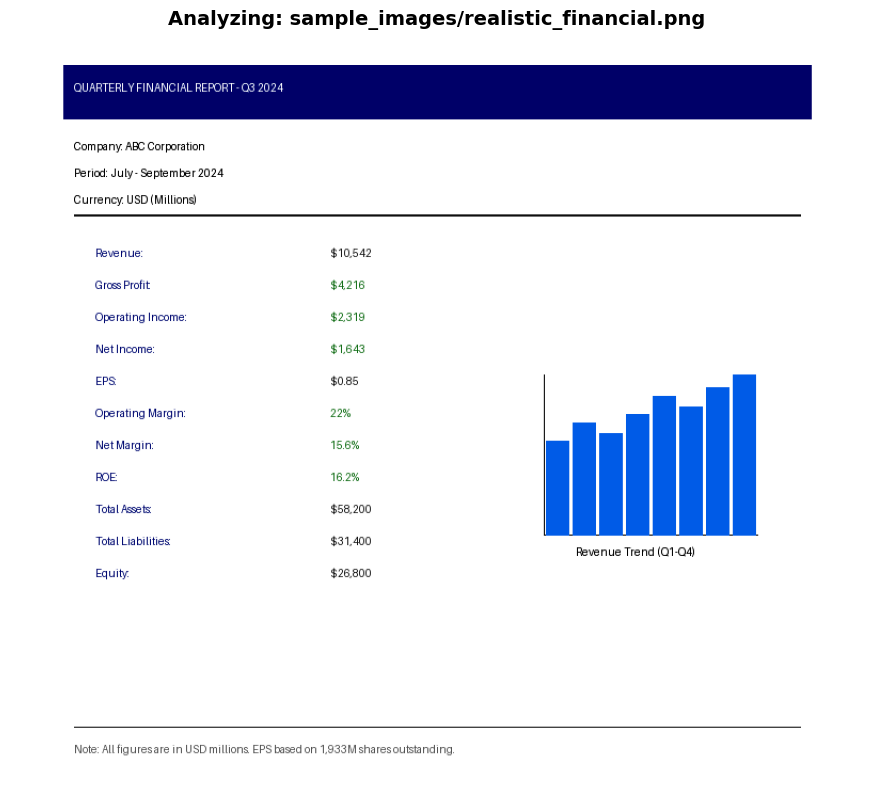

📤 Using model: models/gemini-2.5-flash
⏳ Sending image to Gemini AI for analysis...

📊 ANALYSIS RESULTS

✅ Analysis Successful!
🔍 Model Used: models/gemini-2.5-flash
📂 Image: sample_images/realistic_financial.png

📈 Extracted Metrics:
  • Revenue: ,
  • Net Income: 1,643
  • Equity: .

📝 Full Analysis:
----------------------------------------
Here's a structured financial analysis of ABC Corporation based on the provided Q3 2024 financial report:

**Company:** ABC Corporation
**Period:** July - September 2024 (Q3 2024)
**Currency:** USD (Millions)

---

1.  **Key Financial Metrics Found:**

    *   **Revenue:** $10,542 Million
    *   **Gross Profit:** $4,216 Million
    *   **Operating Income:** $2,319 Million
    *   **Net Income:** $1,643 Million
    *   **EPS:** $0.85 (based on 1,933M shares outstanding)
    *   **Operating Margin:** 22%
    *   **Net Margin:** 15.6%
    *   **ROE (Return on Equity):** 16.2%
    *   **Total Assets:** $58,200 Million
    *   **Total Liabilities:** $

In [ ]:
# Test the analysis on our realistic financial image
print("="*60)
print("🧪 TESTING ANALYSIS ON SAMPLE IMAGE")
print("="*60)

result = analyze_financial_image(
    'sample_images/realistic_financial.png',
    model_name='models/gemini-2.5-flash'
)

print("\n" + "="*60)
print("📊 ANALYSIS RESULTS")
print("="*60)

if "error" in result:
    print(f"❌ Error: {result['error']}")
else:
    print(f"\n✅ Analysis Successful!")
    print(f"🔍 Model Used: {result.get('model_used', 'Unknown')}")
    print(f"📂 Image: {result.get('image_processed', 'Unknown')}")
    
    print("\n📈 Extracted Metrics:")
    if result.get("metrics"):
        for key, value in result["metrics"].items():
            print(f"  • {key}: {value}")
    else:
        print("  No metrics extracted")
    
    print("\n📝 Full Analysis:")
    print("-" * 40)
    print(result.get("analysis_text", "No analysis available"))
    print("-" * 40)

print("\n" + "="*60)
print("✅ Sample Analysis Complete!")
print("="*60)

In [ ]:
def analyze_any_image():
    """
    Interactive function to analyze any financial image
    """
    print("\n" + "="*60)
    print("📊 INTERACTIVE FINANCIAL IMAGE ANALYZER")
    print("="*60)
    print("\n📌 Enter the path to your financial image:")
    print("   • Local file: sample_images/your_image.png")
    print("   • URL: https://example.com/image.png")
    print("   • Press Enter to use sample image")
    print("-" * 40)
    
    # Get user input
    image_path = input("📂 Image path: ").strip()
    
    # Use sample image if empty
    if not image_path:
        image_path = 'sample_images/realistic_financial.png'
        print(f"ℹ️ Using sample image: {image_path}")
    
    # Ask for model preference
    print("\n🤖 Choose Gemini model:")
    print("   1. gemini-2.5-flash (Fast, Recommended)")
    print("   2. gemini-2.0-flash (Good)")
    print("   3. gemini-2.5-pro (More detailed, slower)")
    print("-" * 40)
    
    model_choice = input("Select model (1-3): ").strip()
    
    model_map = {
        '1': 'models/gemini-2.5-flash',
        '2': 'models/gemini-2.0-flash',
        '3': 'models/gemini-2.5-pro'
    }
    model_name = model_map.get(model_choice, 'models/gemini-2.5-flash')
    print(f"ℹ️ Using model: {model_name}")
    
    # Analyze the image
    print("\n" + "-" * 40)
    print("🔄 Starting analysis...")
    print("-" * 40)
    
    result = analyze_financial_image(image_path, model_name=model_name)
    
    # Display results
    print("\n" + "="*60)
    print("📊 ANALYSIS RESULTS")
    print("="*60)
    
    if "error" in result:
        print(f"❌ Error: {result['error']}")
    else:
        print(f"\n✅ Analysis Successful!")
        print(f"🔍 Model Used: {result.get('model_used', 'Unknown')}")
        
        print("\n📈 Extracted Metrics:")
        if result.get("metrics"):
            for key, value in result["metrics"].items():
                print(f"  • {key}: {value}")
        else:
            print("  No metrics extracted")
        
        print("\n📝 Full Analysis:")
        print("-" * 40)
        print(result.get("analysis_text", "No analysis available"))
        print("-" * 40)
    
    print("\n" + "="*60)
    print("✅ Analysis Complete!")
    print("="*60)

print("✅ Interactive analysis function ready!")
print("\n📖 To use: Run 'analyze_any_image()' in the next cell")

✅ Interactive analysis function ready!

📖 To use: Run 'analyze_any_image()' in the next cell



📊 QUICK TEST WITH SAMPLE IMAGE
📂 Attempt 1/2
📁 Loading image from file: sample_images/realistic_financial.png
✅ Image loaded successfully! Size: (800, 700)
   ✨ Contrast enhanced


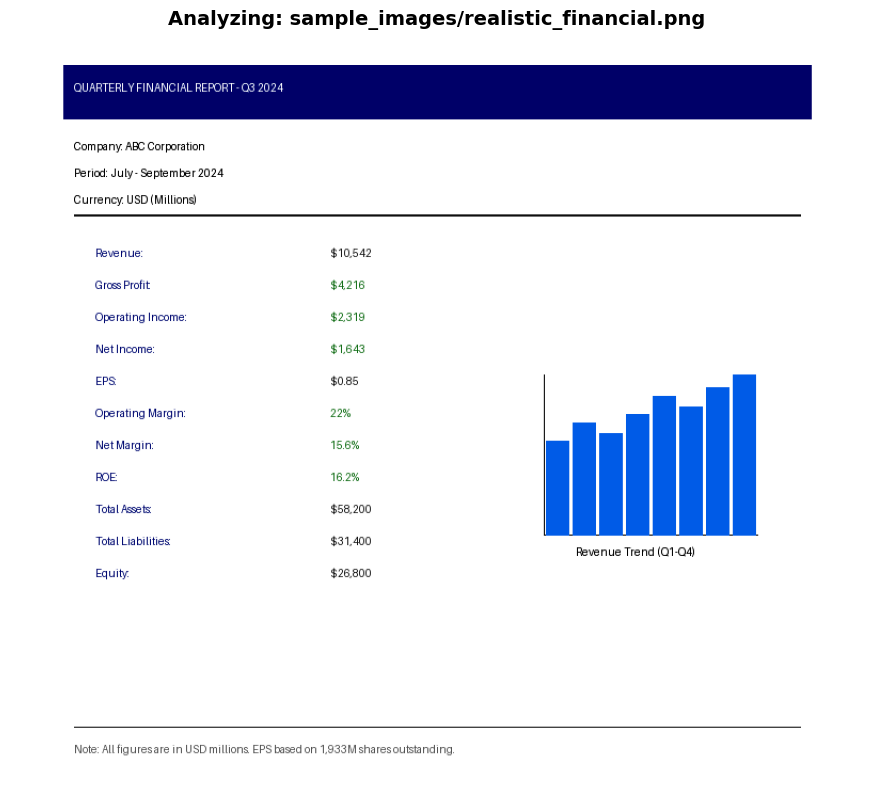

📤 Using model: models/gemini-2.5-flash
⏳ Sending image to Gemini AI for analysis...

✅ Quick Test Complete!
📈 Metrics Found: 3
   • Revenue
   • EPS
   • Equity


In [ ]:
# Run the interactive analyzer
# Uncomment the line below to run interactively

# analyze_any_image()

# Or run a quick test with sample image
print("\n" + "="*60)
print("📊 QUICK TEST WITH SAMPLE IMAGE")
print("="*60)

# Quick analysis without interactive prompts
quick_result = analyze_financial_image(
    'sample_images/realistic_financial.png',
    model_name='models/gemini-2.5-flash'
)

print("\n✅ Quick Test Complete!")
print(f"📈 Metrics Found: {len(quick_result.get('metrics', {}))}")
if quick_result.get("metrics"):
    print("   • " + "\n   • ".join(quick_result["metrics"].keys()))